In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
from tqdm import tqdm

In [33]:
def generate_anchors_positions(positions_segments, attach):
    positions_anchors = np.zeros((len(attach), 3))

    for idx, a in enumerate(attach):
        positions_anchors[idx] = np.random.normal(positions_segments[a], np.sqrt(Re**2/(3*(N-1)*beta)))
        
        # print(idx, a, positions_segments[a])
    return positions_anchors

def bonded_energy(positions_segments):
    u = 0
    for segment in range(1, len(positions_segments)):
        u += np.linalg.norm(positions_segments[segment] - positions_segments[segment-1])**2

    return u

def slipSpring_energy(positions_segments, positions_anchors, anchor):
    w = 0
    
    for idx, a in enumerate(anchor):
        if a == -1:
            continue
        else:
            w += np.linalg.norm(positions_segments[idx] - positions_anchors[a])**2
        print(a, positions_segments[idx], positions_anchors[a])
    return w

def hamiltonian(positions_segments, positions_anchors, anchor):
    h = bonded_energy(positions_segments) + beta*slipSpring_energy(positions_segments, positions_anchors, anchor)
    h *= -3*(N-1)/(2*Re**2)
    return h

In [11]:
def plotter(positions_segments, anchor, positions_anchors, flag_initial=True):
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')

    # Chain backbone
    ax.plot(positions_segments[:, 0], positions_segments[:, 1], positions_segments[:, 2], "-", color="k", alpha=0.5)

    # Beads
    for segment in range(len(positions_segments)):
        if anchor[segment] == -1:
            ax.scatter(*positions_segments[segment], color="k", facecolors="none", alpha=0.8)
        else:
            ax.scatter(*positions_segments[segment], color="k", alpha=0.8)

    # Chain ends
    ax.scatter(*positions_segments[0], color="b", marker="s", s=60, facecolors="none", label="bead N=1")
    ax.scatter(*positions_segments[-1], color="g", marker="s", s=60, facecolors="none", label=f"bead N={len(positions_segments)}")

    # Anchor connections
    for idx, a in enumerate(anchor):
        if a != -1:
            ax.plot(
                [positions_anchors[a, 0], positions_segments[idx, 0]],
                [positions_anchors[a, 1], positions_segments[idx, 1]],
                [positions_anchors[a, 2], positions_segments[idx, 2]],
                color='red', linestyle='-', linewidth=1, alpha=0.4
            )
            ax.scatter(
                *positions_anchors[a],
                color='red', marker="s", alpha=0.4, s=10
            )

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    ax.legend(loc="upper right")
    ax.grid(False)

    if flag_initial:
        ax.set_title("Initial Configuration")
    fig.tight_layout()
    

In [12]:
# System Parameters

N = 64 # Number of segments
Z = N//4 # Number of slip links

Re = 1 # Polymer end-to-end distance
beta = 0.5 # Anchor-segment stiffness (?)


dims = 3 # Space dimensions

N_steps = 100

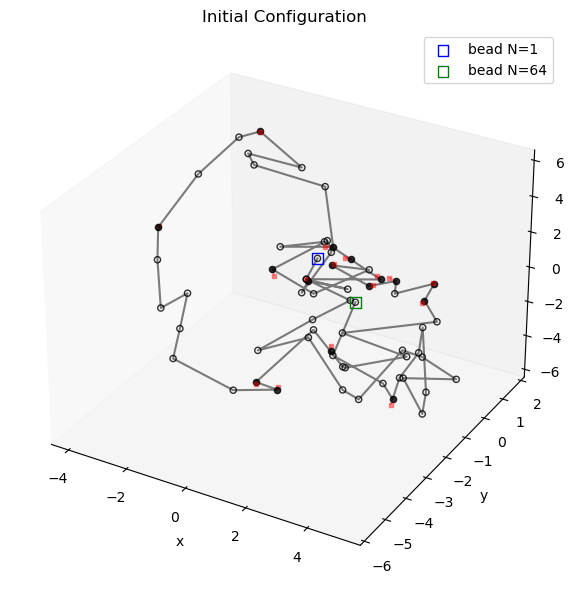

In [14]:
# Initialize the system

# Initialize polymer
positions_segments = np.zeros((N, dims))

# whereby, assumed that the first segment is initialized at (0, 0, 0)
for segment in range(1, N):
    # print(segment)
    positions_segments[segment] = positions_segments[segment-1] + np.random.normal(0, 1, dims)

# Beads with slip-springs
# Get the index of the beads with the slip spring
attach = np.random.choice(N, Z, replace=False)

# "idx-ordered" list of slip springs (similar to a hash table)
anchor = -1*np.ones(N, dtype=np.int64)
for idx, link in enumerate(attach):
    anchor[link] = idx

positions_anchors = generate_anchors_positions(positions_segments, attach)

# Visualize initial config.
plotter(positions_segments, anchor, positions_anchors, flag_initial=True)